In [ ]:
#pip install matplotlib scikit-learn opencv-python


# Downgrade NumPy
!pip install numpy==1.25.2 --force-reinstall

# Reinstall Pillow
!pip install --upgrade --force-reinstall pillow

# Verify versions
!python -c "import numpy; import tensorflow as tf; import PIL; print('NumPy:', numpy.__version__, 'TensorFlow:', tf.__version__, 'PIL:', PIL.__version__)"


pip install pillow


In [1]:
import tensorflow as tf
print(tf.__version__)


2.16.2


In [ ]:
import sys
print(sys.version)


3.12.1 (v3.12.1:2305ca5144, Dec  7 2023, 17:23:38) [Clang 13.0.0 (clang-1300.0.29.30)]


Importing Libraries
- tensorflow , deep learning framework
- layers , neural network building blocks
- models, provides model containers like Sequential

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(64,64,3)),                  # Input layer for 64x64 RGB images (3 channels )
    layers.Conv2D(8, (3,3), activation='relu'),     # Convolutional layer with 8 filters, 3x3 kernel, ReLU activation- Extracts features from the input images
    layers.Flatten(),                               # Flattens the 2D feature maps into a 1D vector                   
    layers.Dense(2, activation='softmax')           # Output layer with 2 neurons for binary classification using softmax activation
    ])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')     # Compiles the model with Adam optimizer and sparse categorical crossentropy loss function
print("Model compiled")

Model compiled


In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 0


pip install tensorflow-metal

In [ ]:
pip install tensorflow-metal

  Obtaining dependency information for tensorflow-metal from https://files.pythonhosted.org/packages/dc/bf/988b619322d5617a928e7f31cbb1ed8dd7f375f69dfa73dab26409a00382/tensorflow_metal-1.2.0-cp312-cp312-macosx_12_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.7 MB/s eta 0:00:00ta 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install tensorflow-macos==2.13 tensorflow-metal==1.1.0


ERROR: Could not find a version that satisfies the requirement tensorflow-macos==2.13 (from versions: 2.16.0rc0, 2.16.1, 2.16.2)
ERROR: No matching distribution found for tensorflow-macos==2.13

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip uninstall tensorflow tensorflow-macos tensorflow-metal -y


In [ ]:
pip install tensorflow-macos==2.20 tensorflow-metal

ERROR: Could not find a version that satisfies the requirement tensorflow-macos==2.20 (from versions: 2.16.0rc0, 2.16.1, 2.16.2)
ERROR: No matching distribution found for tensorflow-macos==2.20

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#install pytorch builds for macOS with M1/M2 GPU support
pip install torch torchvision torchaudio


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())


PyTorch version: 2.9.1
MPS available: True
MPS built: True


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


Using device: mps


In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))


2.16.2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [49]:
! pip show tensorflow-macos
! pip show tensorflow-metal


Name: tensorflow-macos
Version: 2.16.2
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /Users/swostikshrestha/Documents/deepu/thesis/practical/.venv/lib/python3.12/site-packages
Requires: tensorflow
Required-by: 
Name: tensorflow-metal
Version: 1.2.0
Summary: TensorFlow acceleration for Mac GPUs.
Home-page: https://developer.apple.com/metal/tensorflow-plugin/
Author: 
Author-email: 
License: MIT License. Copyright © 2020-2021 Apple Inc. All rights reserved.
Location: /Users/swostikshrestha/Documents/deepu/thesis/practical/.venv/lib/python3.12/site-packages
Requires: six, wheel
Required-by: 


In [ ]:
import tensorflow as tf
import time
import matplotlib.pyplot as plt
import os
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models



# Generate random matrices
a = tf.random.normal([10000, 1000])
b = tf.random.normal([1000, 10000])

# --- CPU computation ---
with tf.device('/CPU:0'):
    start_cpu = time.time()
    c_cpu = tf.matmul(a, b)
    end_cpu = time.time()
print("Time taken on CPU:", end_cpu - start_cpu)

# --- GPU computation ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    with tf.device('/GPU:0'):
        start_gpu = time.time()
        c_gpu = tf.matmul(a, b)
        end_gpu = time.time()
    print("Time taken on GPU:", end_gpu - start_gpu)
else:
    print("No GPU found.")




#path to directory
data_dir = 'dataset/chest_xray/chest_xray/test/NORMAL'

#List some files
img_files = os.listdir(data_dir)[:5]

plt.figure(figsize=(15,5))
for i, img_file in enumerate(img_files):
    img_path = os.path.join(data_dir, img_file)
    img = image.load_img(img_path, target_size = (224,224))
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(img_file.split('.')[0])
plt.show()


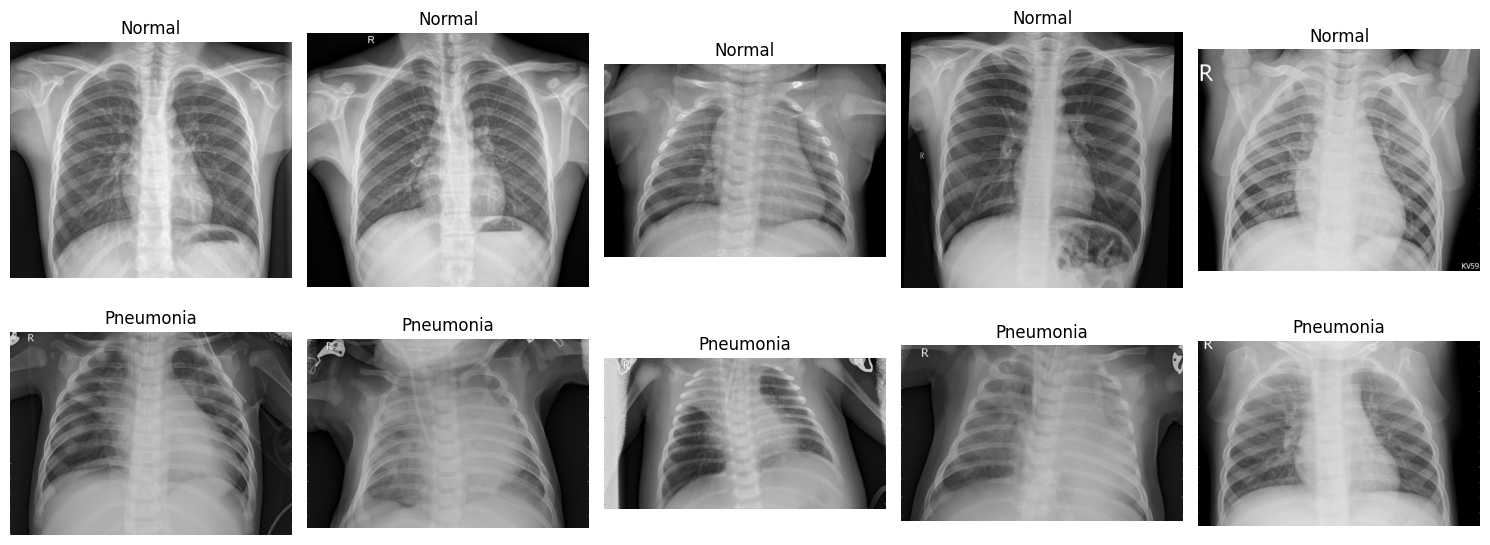

In [ ]:


# Paths to the directories
normal_dir = "dataset/chest_xray/chest_xray/test/NORMAL"
pneumonia_dir = "dataset/chest_xray/chest_xray/test/PNEUMONIA"

# Load 5 images from each
normal_images = [Image.open(os.path.join(normal_dir, img)) for img in os.listdir(normal_dir)[:5]]
pneumonia_images = [Image.open(os.path.join(pneumonia_dir, img)) for img in os.listdir(pneumonia_dir)[:5]]

# Display images
fig, axes = plt.subplots(2, 5, figsize=(15,6))
for i, img in enumerate(normal_images):
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Normal")
    
for i, img in enumerate(pneumonia_images):
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Pneumonia")

plt.tight_layout()
plt.show()


In [ ]:


# Paths
train_dir = "dataset/chest_xray/chest_xray/train"
test_dir = "dataset/chest_xray/chest_xray/test"
val_dir = "dataset/chest_xray/chest_xray/val"

# Image data generator with rescaling
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images in batches
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # resize images
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)



val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


# Build a simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=5,  # start small to test
    validation_data=val_generator
)

# evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print('\nTest accuracy:', test_acc)
print('\nTest loss:', test_loss)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


/Users/swostikshrestha/Documents/deepu/thesis/practical/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 135ms/step - accuracy: 0.7186 - loss: 0.7453 - val_accuracy: 0.6250 - val_loss: 1.2377
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.8840 - loss: 0.3835 - val_accuracy: 0.7500 - val_loss: 0.3402
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - accuracy: 0.9220 - loss: 0.2173 - val_accuracy: 0.8750 - val_loss: 0.3054
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.9576 - loss: 0.1273 - val_accuracy: 0.9375 - val_loss: 0.1142
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - accuracy: 0.9672 - loss: 0.0930 - val_accuracy: 0.8750 - val_loss: 0.3867
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.7612 - loss: 1.0048

Test accuracy: 0.7612179517745972

Test loss: 1.0047746896743774


Those numbers actually tell a pretty clear story:

What happened

Training accuracy climbed to ~0.97 and loss dropped → the model fits the training set very well.

Validation accuracy jumps around (0.62 → 0.94 → 0.88) and val loss swings a lot →  validation set is tiny (Kaggle’s val/ is famously small), so it’s noisy and not very reliable epoch-to-epoch.

Test accuracy ~0.76 with high test loss (~1.00) → generalization is much weaker than training. This is classic overfitting, plus (very likely) threshold/imbalance effects.

Why val looked “great” but test is much lower

Kaggle val/ is extremely small (often only ~16 images total). With a batch size of 32, we are basically validating on a handful of samples, so we can get 0.875 or 0.9375 just by getting 14/16 or 15/16 right.

Train distribution vs test distribution can differ slightly (image quality, positioning, etc.).

Imbalance: accuracy can be misleading if the model leans toward predicting the majority class.


In [ ]:
# using validation_split in ImageDataGenerator

train_dir = "dataset/chest_xray/chest_xray/train"
test_dir  = "dataset/chest_xray/chest_xray/test"

img_size = (150, 150)
batch_size = 32
seed = 123
val_split = 0.2  # 20% of train becomes validation

# One generator that can produce both train + val splits
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)
# flow from directotory call can assign labels from subfolder

# Train subset
train_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=seed
)
# Print class indices to verify label assignment
print(train_generator.class_indices)


# Validation subset
val_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=seed
)

# Test generator (no split here)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# Same model 
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train with early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)


# Final evaluation on untouched test set
test_loss, test_acc = model.evaluate(test_generator)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


Found 4173 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 24s 178ms/step - accuracy: 0.7738 - loss: 0.5740 - val_accuracy: 0.8974 - val_loss: 0.2728
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step - accuracy: 0.9535 - loss: 0.1238 - val_accuracy: 0.9444 - val_loss: 0.1497
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.9667 - loss: 0.0954 - val_accuracy: 0.9310 - val_loss: 0.2048
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - accuracy: 0.9703 - loss: 0.0821 - val_accuracy: 0.9588 - val_loss: 0.1421
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.9736 - loss: 0.0736 - val_accuracy: 0.9549 - val_loss: 0.1411
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 169ms/step - accuracy: 0.9827 - loss: 0.0517 - val_accuracy: 0.9578 - val_loss: 0.1321
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.9813 - loss: 0.0557 - val_accuracy: 0.9607 - val_loss: 0.1411
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accuracy: 0.9851 - loss: 0

Before increaseing the epochs, The training and validation accuracy was high and stable, from about 81% -> 97% for train and similar for val. This is stable than before when we trained using the val dataset from val folder from kaggle because it had very few images. 
Although, the performance on the test is significantly lower than the validation. Possible reason being
- model generalizes too well to the data similar to training (as val data is part of the training data)
- distibution gap between train/val and test
- model has limited generalization capacity on this dataset.


Increasing epochs caused overfitting: validation stayed high, but test performance worsened, confirming that training longer is not the right lever for improvement here.

### With Augmentation

In [ ]:


train_dir = "dataset/chest_xray/chest_xray/train"
test_dir  = "dataset/chest_xray/chest_xray/test"

img_size = (150, 150)
batch_size = 32
seed = 123
val_split = 0.2

# ✅ Augmentation for training only
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split,

    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ✅ No augmentation for validation/test (just rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=seed
)

val_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
).flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=seed
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_generator)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - accuracy: 0.7491 - loss: 0.5543 - val_accuracy: 0.8677 - val_loss: 0.3249
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 232ms/step - accuracy: 0.9044 - loss: 0.2474 - val_accuracy: 0.9089 - val_loss: 0.2330
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 245ms/step - accuracy: 0.9003 - loss: 0.2508 - val_accuracy: 0.8888 - val_loss: 0.3002
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 212ms/step - accuracy: 0.9056 - loss: 0.2319 - val_accuracy: 0.9195 - val_loss: 0.2183
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 231ms/step - accuracy: 0.9200 - loss: 0.2067 - val_accuracy: 0.9147 - val_loss: 0.2573
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 218ms/step - accuracy: 0.9283 - loss: 0.2038 - val_accuracy: 0.9147 - val_loss: 0.2353
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 218ms/step - accuracy: 0.9238 - loss: 0.2081 - val_accuracy: 0.9089 - val_loss: 0.2493
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.7917 - loss: 0.5275
Test acc

### Chaging the augmentation 
Changed the augmentation specifically for x ray images for pneunominia detection to see if it can help the model.

To improve generalization while preserving anatomical realism in chest X-ray images, the data augmentation strategy was modified as follows:

Reduced rotation range
Rotation was limited to small angles (±7°) to simulate minor patient positioning variations during X-ray acquisition without introducing unrealistic distortions.

Reduced translation (shift) magnitude
Horizontal and vertical shifts were restricted to ±3% of the image size to reflect slight centering differences while maintaining full lung visibility.

Moderate zoom range
Zoom augmentation was constrained to ±7% to account for variations in patient–detector distance, avoiding excessive cropping of lung regions.

Added brightness variation
A mild brightness range (0.85–1.15) was introduced to simulate differences in exposure and imaging conditions commonly observed in chest radiographs.

Removed shear transformation
Shear augmentation was eliminated because it introduces geometric distortions that are not physically plausible in chest X-ray imaging and may alter anatomical structures.

Retained horizontal flipping (optional)
Horizontal flipping was kept to improve robustness to left–right variability, while acknowledging that its clinical relevance is debated and should be evaluated empirically.

Applied augmentation only to training data
Validation and test datasets were limited to rescaling only, ensuring that performance metrics reflect true generalization rather than augmented data.

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np

train_dir = "dataset/chest_xray/chest_xray/train"
test_dir  = "dataset/chest_xray/chest_xray/test"

img_size = (150, 150)
batch_size = 32
seed = 123
val_split = 0.2

# ✅ Augmentation for training only
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split,

    rotation_range=7,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.07,
    brightness_range=(0.85, 1.15),
    shear_range=0,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ✅ No augmentation for validation/test (just rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=seed
)

val_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
).flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=seed
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_generator)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

test_generator.reset()
preds = (model.predict(test_generator) > 0.5).astype(int)
print(np.bincount(preds.ravel()))


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 244ms/step - accuracy: 0.6703 - loss: 1.0962 - val_accuracy: 0.6759 - val_loss: 0.5819
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.7958 - loss: 0.4590 - val_accuracy: 0.8533 - val_loss: 0.4043
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 240ms/step - accuracy: 0.8759 - loss: 0.3277 - val_accuracy: 0.9012 - val_loss: 0.2476
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 241ms/step - accuracy: 0.8924 - loss: 0.2737 - val_accuracy: 0.8504 - val_loss: 0.3724
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.9065 - loss: 0.2359 - val_accuracy: 0.9281 - val_loss: 0.1888
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.9185 - loss: 0.1986 - val_accuracy: 0.9156 - val_loss: 0.2194
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.8972 - loss: 0.2992 

The model is underfitting now as the training accuracy remained same from 2nd epoch and training loss stays almost same.
It is most likely that it is predicting a single class for every single image.
- Most probably because the augmentation became too strong relative to the model capacity
- specifically brightness + geometry vision, class imbalance (there are more pneumonia cases than normal in the kaggle dataset)
- The model fails to learn discriminative features and it finds a safe solution i.e. predict the majority class.

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()
probs = model.predict(test_generator).ravel()
preds = (probs >= 0.5).astype(int)
y_true = test_generator.classes

print("Pred counts:", np.bincount(preds))
print("True counts:", np.bincount(y_true))  # how many NORMAL vs PNEUMONIA in test

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=["NORMAL", "PNEUMONIA"]))


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
Pred counts: [100 524]
True counts: [234 390]
[[ 94 140]
 [  6 384]]
              precision    recall  f1-score   support

      NORMAL       0.94      0.40      0.56       234
   PNEUMONIA       0.73      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.81      0.77      0.74       624



Normal (true = 234), correctly predicted = 94 and misclassificed as pneumonia = 140
Pnrumonia ( true = 390), correclty predicted = 384 and misclassificed pneumonia = 6.
Recall --> Did we catch all the pneumonia ? ( yes, we caught 384 out of 394)
Precision --> When model says pneumonia, was it correct ? ( predicted 524 pneumonia out of which 140 was supposed to be normal)
- The model is very conservative, it prefers to say 'pneumonia' unless it is very sure it is normal
The baseline CNN achieves very high sensitivity for pneumonia (98%) at the cost of low specificity for normal cases, indicating a strong class bias driven by dataset imbalance.
- F1 score of 0.56 is poor balance for finding normal while 0.84 f1 for pneumonia is strong performance for pneumonia
- MAcro f1 of 0.70 clearly expose the bias towards one of the classes ( in this case pneumonia)
- Weighted average of 0.74 tells us that it performes well in the pneumonia cases since they are the most common in the dataset

In [22]:
# Try multiple thresholds

test_generator.reset()
probs = model.predict(test_generator).ravel()

for t in [0.5, 0.55, 0.6, 0.65]:
    preds = (probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(test_generator.classes, preds,
                                target_names=["NORMAL", "PNEUMONIA"]))


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step

Threshold = 0.5
              precision    recall  f1-score   support

      NORMAL       0.94      0.40      0.56       234
   PNEUMONIA       0.73      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.81      0.77      0.74       624


Threshold = 0.55
              precision    recall  f1-score   support

      NORMAL       0.93      0.43      0.59       234
   PNEUMONIA       0.74      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.70      0.72       624
weighted avg       0.81      0.77      0.75       624


Threshold = 0.6
              precision    recall  f1-score   support

      NORMAL       0.94      0.44      0.60       234
   PNEUMONIA       0.75      0.98      0.85       390

    accuracy                           0.78       624
   macro avg       0.84      0.71  

Adjusting the threshold from 0.5 to 0.65 improved class balance which can be seen from the increasing macro avg f1 score from 0.70 to 0.73 while maintaining a good recall for pneumonia at 0.98.
Threshold tuning rebalances errors without changing the model and in this case.

- This result sohows that meaningful permonace gains can be achieved through decision level optimization without increasing model complexity, in this case chaing the threshold.
- Although the absolute increase in macro f1-score is modest, the improvement is achieved without any increase in model complexity or computation cost and results in measurable reduction in false positive pneumonia predictions.

In [26]:
# Find best threshold on validation set

import numpy as np
from sklearn.metrics import f1_score

# Make sure this is your VAL generator, not test
val_generator.reset()
val_probs = model.predict(val_generator, verbose=0).ravel()
y_val = val_generator.classes

thresholds = np.linspace(0.05, 0.95, 181)  # step=0.005
macro_f1s = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    macro_f1s.append(f1_score(y_val, preds, average="macro"))

best_idx = int(np.argmax(macro_f1s))
best_t = float(thresholds[best_idx])
best_macro_f1 = float(macro_f1s[best_idx])

print("Best threshold (val):", best_t)
print("Best macro F1 (val):", best_macro_f1)


Best threshold (val): 0.835
Best macro F1 (val): 0.9196563693614581


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_generator.reset()
test_probs = model.predict(test_generator, verbose=0).ravel()
y_test = test_generator.classes

t = best_t
preds = (test_probs >= t).astype(int)

print("Using threshold:", t)
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, target_names=["NORMAL", "PNEUMONIA"]))
print("Macro F1 (test):", f1_score(y_test, preds, average="macro"))
print("Weighted F1 (test):", f1_score(y_test, preds, average="weighted"))


Using threshold: 0.835
[[137  97]
 [ 12 378]]
              precision    recall  f1-score   support

      NORMAL       0.92      0.59      0.72       234
   PNEUMONIA       0.80      0.97      0.87       390

    accuracy                           0.83       624
   macro avg       0.86      0.78      0.79       624
weighted avg       0.84      0.83      0.81       624

Macro F1 (test): 0.7946965695226309
Weighted F1 (test): 0.8145195369685627



Threshold = 0.7
Pred counts: [118 506]
True counts: [234 390]
[[111 123]
 [  7 383]]
              precision    recall  f1-score   support

      NORMAL       0.94      0.47      0.63       234
   PNEUMONIA       0.76      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.85      0.73      0.74       624
weighted avg       0.83      0.79      0.77       624

Macro F1: 0.7427962662337663
Weighted F1: 0.7708248782467533

Threshold = 0.835
Pred counts: [149 475]
True counts: [234 390]
[[137  97]
 [ 12 378]]
              precision    recall  f1-score   support

      NORMAL       0.92      0.59      0.72       234
   PNEUMONIA       0.80      0.97      0.87       390

    accuracy                           0.83       624
   macro avg       0.86      0.78      0.79       624
weighted avg       0.84      0.83      0.81       624

Macro F1: 0.7946965695226309
Weighted F1: 0.8145195369685627


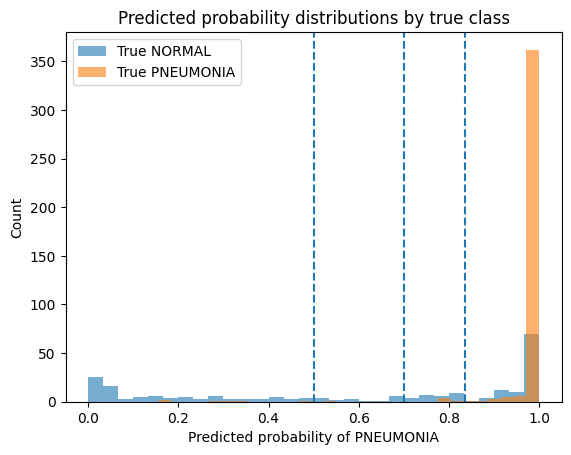

In [29]:
# plotting probability distributions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# If your generator isn't named test_generator, rename it here:
# test_generator = YOUR_TEST_GENERATOR_VARIABLE

test_generator.reset()
probs = model.predict(test_generator, verbose=0).ravel()
y_true = test_generator.classes

def eval_at_threshold(thr):
    preds = (probs >= thr).astype(int)
    print(f"\nThreshold = {thr}")
    print("Pred counts:", np.bincount(preds))
    print("True counts:", np.bincount(y_true))
    print(confusion_matrix(y_true, preds))
    print(classification_report(y_true, preds, target_names=["NORMAL", "PNEUMONIA"]))
    print("Macro F1:", f1_score(y_true, preds, average="macro"))
    print("Weighted F1:", f1_score(y_true, preds, average="weighted"))

# Evaluate 0.70 (and you can compare to 0.65 too)
eval_at_threshold(0.70)
eval_at_threshold(0.835)

# Plot probability distributions by true class
mask_normal = (y_true == 0)
mask_pneu   = (y_true == 1)

plt.figure()
plt.hist(probs[mask_normal], bins=30, alpha=0.6, label="True NORMAL")
plt.hist(probs[mask_pneu],   bins=30, alpha=0.6, label="True PNEUMONIA")
plt.axvline(0.5, linestyle="--")
plt.axvline(0.70, linestyle="--")
plt.axvline(0.835, linestyle="--")
plt.xlabel("Predicted probability of PNEUMONIA")
plt.ylabel("Count")
plt.title("Predicted probability distributions by true class")
plt.legend()
plt.show()


The probability distribution reveals strong separation for pneumonia cases, which cluster near high confidence values(1- Pneumonia), while normal cases exhibit broader uncertainty. Increasing the decision threshold reduces false positive pneumonia predictions without substantially affecting pneumonia recall

### ROC and PR plots

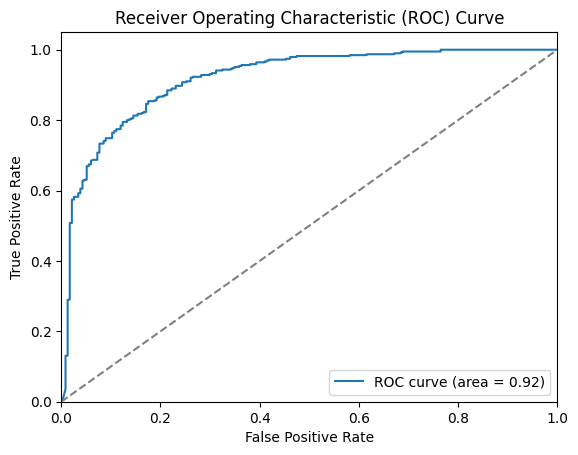

In [30]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

test_generator.reset()
probs = model.predict(test_generator, verbose=0).ravel()
y_true = test_generator.classes
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

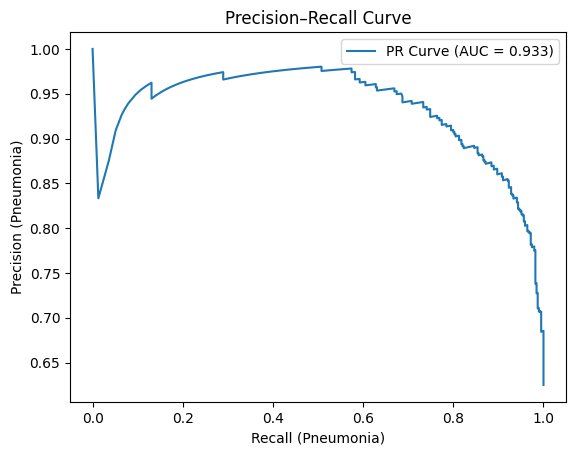

In [32]:
precision, recall, pr_thresholds = precision_recall_curve(y_true, probs)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall (Pneumonia)")
plt.ylabel("Precision (Pneumonia)")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()


- The PR curve is generated by sweeping the threshold from very hig to very lo. The left side corresponds to very high thresholds. The very left is where threshold = 1.0 and almost no image has prob >=1 so precision = 1 ( no false positives) and recall = 0 (almost no images have prob above the threshold so no pneumonia found).
- As we move right and the threshold decreases, more pneumonia cases are detected --> recall increases and more normal cases are misclassified as pneumonia --> precision decreases.
- At the very right end, when threshold is closer to 0.0, every image will be detected as pneumonia, hence recall = 1 ( all pneumonia images are found), while precision is lower than 0.65 which is the fraction of pneumonia of dataset.
- The left side of the PR curve corresponds to very high thresholds because the precision–recall curve is constructed by evaluating the model at decreasing threshold values. At high thresholds, the model makes very few positive predictions, resulting in high precision and low recall. As the threshold decreases, recall increases and precision gradually drops.

In [38]:
# Clear TensorFlow session to free up resources
import tensorflow as tf
tf.keras.backend.clear_session()
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.16.2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
# Build a simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()


/Users/swostikshrestha/Documents/deepu/thesis/practical/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
import numpy as np

counts = np.bincount(train_generator.classes)  # [NORMAL, PNEUMONIA]
total = counts.sum()

class_weight = {
    0: total / (2 * counts[0]),  # NORMAL weight
    1: total / (2 * counts[1])   # PNEUMONIA weight
}

print("Class counts:", counts)
print("Class weights:", class_weight)


Class counts: [1073 3100]
Class weights: {0: 1.9445479962721341, 1: 0.6730645161290323}


In [41]:

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=callbacks
)



Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 35s 261ms/step - accuracy: 0.7438 - loss: 0.6149 - val_accuracy: 0.9147 - val_loss: 0.2033
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 246ms/step - accuracy: 0.8926 - loss: 0.2630 - val_accuracy: 0.9243 - val_loss: 0.2144
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.9264 - loss: 0.1928 - val_accuracy: 0.9511 - val_loss: 0.1360
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 230ms/step - accuracy: 0.9331 - loss: 0.1738 - val_accuracy: 0.9578 - val_loss: 0.1282
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 233ms/step - accuracy: 0.9418 - loss: 0.1465 - val_accuracy: 0.9511 - val_loss: 0.1265
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 237ms/step - accuracy: 0.9434 - loss: 0.1556 - val_accuracy: 0.9655 - val_loss: 0.0938
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.9461 - loss: 0.1499 - val_accuracy: 0.9415 - val_loss: 0.1767
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.9444 - loss: 0

In [42]:
test_generator.reset()
probs = model.predict(test_generator).ravel()
preds = (probs >= 0.835).astype(int)
y_true = test_generator.classes

print("Pred counts:", np.bincount(preds))
print("True counts:", np.bincount(y_true))  # how many NORMAL vs PNEUMONIA in test

print(confusion_matrix(y_true, preds))
print(classification_report(y_true, preds, target_names=["NORMAL", "PNEUMONIA"]))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
Pred counts: [172 452]
True counts: [234 390]
[[156  78]
 [ 16 374]]
              precision    recall  f1-score   support

      NORMAL       0.91      0.67      0.77       234
   PNEUMONIA       0.83      0.96      0.89       390

    accuracy                           0.85       624
   macro avg       0.87      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624



In [43]:
# Find best threshold on validation set

import numpy as np
from sklearn.metrics import f1_score

# Make sure this is your VAL generator, not test
val_generator.reset()
val_probs = model.predict(val_generator, verbose=0).ravel()
y_val = val_generator.classes

thresholds = np.linspace(0.05, 0.95, 181)  # step=0.005
macro_f1s = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    macro_f1s.append(f1_score(y_val, preds, average="macro"))

best_idx = int(np.argmax(macro_f1s))
best_t = float(thresholds[best_idx])
best_macro_f1 = float(macro_f1s[best_idx])

print("Best threshold (val):", best_t)
print("Best macro F1 (val):", best_macro_f1)


Best threshold (val): 0.37499999999999994
Best macro F1 (val): 0.9589198053587222


In [1]:
from utils import evaluate


In [44]:
t = 0.375

test_generator.reset()
test_probs = model.predict(test_generator).ravel()
y_test = test_generator.classes
preds = (test_probs >= t).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, target_names=["NORMAL", "PNEUMONIA"]))
print("Macro F1 (test):", f1_score(y_test, preds, average="macro"))


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
[[ 90 144]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.97      0.38      0.55       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.69      0.70       624
weighted avg       0.82      0.76      0.73       624

Macro F1 (test): 0.6954247975375789


In [45]:
print("Validation samples:", val_generator.samples)
print("Validation class counts:", np.bincount(val_generator.classes))


Validation samples: 1043
Validation class counts: [268 775]


In [46]:
print("Train counts:", np.bincount(train_generator.classes))
print("Val counts:", np.bincount(val_generator.classes))
print("Test counts:", np.bincount(test_generator.classes))


Train counts: [1073 3100]
Val counts: [268 775]
Test counts: [234 390]
